In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

input_path = "/content/drive/MyDrive/student-risk-ml-project/data/processed/student_encoded.csv"

df = pd.read_csv(input_path)

print("Shape:", df.shape)
df.head()

Shape: (649, 46)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Fjob_other,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other
0,0,0,18,1,1,0,4,4,2,2,...,0,0,1,1,0,0,0,0,1,0
1,0,0,17,1,1,1,1,1,1,2,...,1,0,0,1,0,0,0,1,0,0
2,0,0,15,1,0,1,1,1,1,2,...,1,0,0,0,0,1,0,0,1,0
3,0,0,15,1,1,1,4,2,1,3,...,0,1,0,0,1,0,0,0,1,0
4,0,0,16,1,1,1,3,3,1,2,...,1,0,0,0,1,0,0,1,0,0


In [3]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Categorical columns:",
      df.select_dtypes(include="object").columns.tolist())

Missing values: 0
Duplicate rows: 0
Categorical columns: []


In [4]:
df["At_Risk"] = (df["G3"] < 10).astype(int)

In [5]:
df[["G3", "At_Risk"]].head(10)

,G3,At_Risk
0,11,0
1,11,0
2,12,0
3,14,0
4,13,0
5,13,0
6,13,0
7,13,0
8,17,0
9,13,0


In [6]:
print(df["At_Risk"].value_counts())

At_Risk
0    549
1    100
Name: count, dtype: int64


In [7]:
print(df["At_Risk"].value_counts(normalize=True) * 100)

At_Risk
0    84.59168
1    15.40832
Name: proportion, dtype: float64


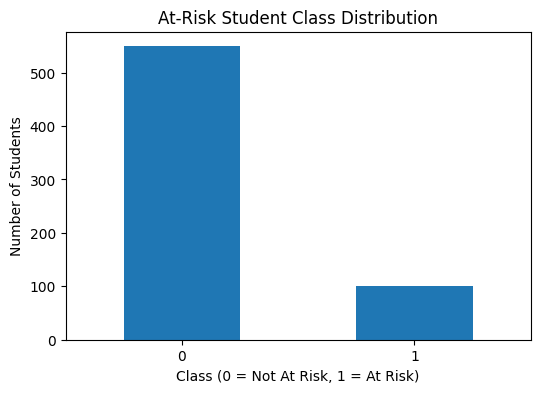

In [8]:
risk_counts = df["At_Risk"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
risk_counts.plot(kind="bar")

plt.title("At-Risk Student Class Distribution")
plt.xlabel("Class (0 = Not At Risk, 1 = At Risk)")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

plt.show()

In [9]:
features_to_remove = ["G1", "G2", "G3"]

ml_df = df.drop(columns=features_to_remove)

print("Original shape:", df.shape)
print("ML-ready shape:", ml_df.shape)

Original shape: (649, 47)
ML-ready shape: (649, 44)


### **Grade Feature Decision**

G3 was removed because the At_Risk target was directly created from G3, making it a direct leakage feature.

G1 and G2 were also excluded from the main model to support early intervention. These grades are collected during the academic period and may not be available when the institution wants to identify students at an earlier stage.

This makes the model more useful as an early-warning system rather than simply using previous grades to predict the final outcome.

In [11]:
X = ml_df.drop(columns=["At_Risk"])
y = ml_df["At_Risk"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (649, 43)
Target shape: (649,)


In [12]:
correlations = ml_df.corr(numeric_only=True)["At_Risk"].sort_values()

print(correlations)

higher              -0.309708
studytime           -0.165111
Fedu                -0.146249
Medu                -0.144803
address             -0.126663
reason_reputation   -0.123914
Mjob_teacher        -0.096404
internet            -0.088215
guardian_father     -0.076162
reason_home         -0.060466
Fjob_teacher        -0.047490
activities          -0.047276
famrel              -0.044987
famsup              -0.037903
schoolsup           -0.034527
Mjob_health         -0.022766
Fjob_other          -0.021943
Mjob_services       -0.020504
Fjob_health         -0.012556
Pstatus              0.004241
nursery              0.007751
Fjob_at_home         0.009168
health               0.009979
Mjob_other           0.019592
guardian_mother      0.045609
guardian_other       0.047062
Fjob_services        0.048640
famsize              0.052215
paid                 0.053708
traveltime           0.057869
goout                0.067241
sex                  0.078222
romantic             0.081177
Mjob_at_ho

In [13]:
constant_features = [
    col for col in X.columns
    if X[col].nunique() <= 1
]

print("Constant features:", constant_features)

Constant features: []


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [15]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (519, 43)
X_test : (130, 43)
y_train: (519,)
y_test : (130,)


In [16]:
print("Training distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training distribution:
At_Risk
0    84.585742
1    15.414258
Name: proportion, dtype: float64

Testing distribution:
At_Risk
0    84.615385
1    15.384615
Name: proportion, dtype: float64


In [17]:
import os

processed_dir = "/content/drive/MyDrive/student-risk-ml-project/data/processed"

os.makedirs(processed_dir, exist_ok=True)

output_path = processed_dir + "/student_ml_ready.csv"

ml_df.to_csv(output_path, index=False)

print("Saved successfully:")
print(output_path)

Saved successfully:
/content/drive/MyDrive/student-risk-ml-project/data/processed/student_ml_ready.csv


In [18]:
check_df = pd.read_csv(output_path)

print("Shape:", check_df.shape)
print("Missing values:", check_df.isnull().sum().sum())
print("Categorical columns:",
      check_df.select_dtypes(include="object").columns.tolist())

print("Contains G1:", "G1" in check_df.columns)
print("Contains G2:", "G2" in check_df.columns)
print("Contains G3:", "G3" in check_df.columns)
print("Contains target:", "At_Risk" in check_df.columns)

Shape: (649, 44)
Missing values: 0
Categorical columns: []
Contains G1: False
Contains G2: False
Contains G3: False
Contains target: True


## **Member 3 — Feature Engineering and Dataset Preparation Summary**

The encoded Student Performance dataset was prepared for machine-learning development.

The binary target variable `At_Risk` was created from the final grade G3:

- At Risk = G3 < 10
- Not At Risk = G3 >= 10

The target distribution was investigated and was found to be imbalanced, with fewer At-Risk students than Not At-Risk students.

G3 was removed from the model inputs because the target was directly derived from G3, which would cause target leakage.

G1 and G2 were also excluded from the main feature set to support the project's early-intervention objective and avoid relying on grades collected later during the academic period.

The final data was separated into features X and target y.

An 80/20 stratified train-test split with `random_state=42` was selected to maintain class proportions and ensure reproducibility.

Feature scaling was not applied globally. Scaling will only be applied to algorithms that require it and will be fitted using training data only to avoid data leakage.

The final prepared dataset was saved as `student_ml_ready.csv`.